# Lightweight Alignment of Vision-Language Representations via Embedding Denoising

## Complete Research Pipeline

This notebook implements:
1. Dataset loading and preparation
2. Baseline: Contrastive fine-tuning
3. Diffusion alignment module (1D U-Net + training)
4. Evaluation and comparison
5. Hyperparameter ablation studies


## Step 1: Setup and Dataset Loading


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Load dataset
dataset = load_dataset("SKyu/my-image-captioning-dataset")

# Consistent dataset splits for all experiments
train_dataset = dataset["train"].select(range(2000, 3000))  # 1000 samples
val_dataset = dataset["train"].select(range(1, 1000))      # 999 samples
test_dataset = dataset["train"].select(range(1000, 2000))  # 1000 samples

print(f"Train: {len(train_dataset)} samples")
print(f"Val: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Train: 1000 samples
Val: 999 samples
Test: 1000 samples


In [3]:
# Data collation function
def collate_fn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [4]:
# Load frozen CLIP model (used by both methods)
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

# Freeze CLIP for embedding extraction
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

# Helper function to get CLIP embeddings
@torch.no_grad()
def get_clip_embeddings(images, captions):
    """Extract normalized CLIP embeddings"""
    inputs = processor(
        text=captions, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=77
    ).to(device)

    img_embeds = F.normalize(
        clip_model.get_image_features(inputs["pixel_values"]), dim=-1
    )
    text_inputs = {k: v for k, v in inputs.items()
                   if k in ["input_ids", "attention_mask"]}
    txt_embeds = F.normalize(
        clip_model.get_text_features(**text_inputs), dim=-1
    )
    return img_embeds, txt_embeds


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Step 2: Baseline - Contrastive Fine-Tuning


In [5]:
# Create a copy of CLIP for fine-tuning (baseline method)
baseline_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)
baseline_model.train()

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-6)

print("Training baseline (contrastive fine-tuning)...")
num_epochs_baseline = 10
baseline_train_losses = []

for epoch in range(num_epochs_baseline):
    baseline_model.train()
    epoch_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_baseline}"):
        inputs = processor(
            text=captions, images=images, return_tensors="pt",
            padding=True, truncation=True, max_length=77
        ).to(device)

        outputs = baseline_model(**inputs)
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        batch_size = logits_per_image.size(0)
        labels = torch.arange(batch_size, device=device)

        # Contrastive loss (cross-entropy on similarity matrix)
        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i + loss_t) / 2

        baseline_optimizer.zero_grad()
        loss.backward()
        baseline_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    baseline_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

print("✅ Baseline training complete!")


Training baseline (contrastive fine-tuning)...


Epoch 1/10: 100%|██████████| 32/32 [00:59<00:00,  1.87s/it]


Epoch 1, Avg Loss: 0.7508


Epoch 2/10: 100%|██████████| 32/32 [00:56<00:00,  1.75s/it]


Epoch 2, Avg Loss: 0.3427


...

Epoch 8, Avg Loss: 0.0546


Epoch 9/10: 100%|██████████| 32/32 [00:34<00:00,  1.09s/it]


Epoch 9, Avg Loss: 0.0476


Epoch 10/10: 100%|██████████| 32/32 [00:34<00:00,  1.08s/it]

Epoch 10, Avg Loss: 0.0450
✅ Baseline training complete!


## Step 3: Diffusion Alignment Module - 1D U-Net Architecture


In [6]:
class UNet1DResidualDenoiser(nn.Module):
    """
    1D U-Net Residual Denoiser for CLIP embeddings
    Cross-modal conditioning: uses text to denoise images (and vice versa)
    """
    def __init__(self, embedding_dim=512, hidden_dim=1024):
        super().__init__()

        # Encoder (takes residual + conditioning)
        self.enc1 = nn.Linear(embedding_dim * 2, hidden_dim)  # *2 for cross-modal conditioning
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)

        # Decoder
        self.dec1 = nn.Linear(hidden_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, embedding_dim)

        self.act = nn.ReLU()

    def forward(self, x_noisy, x_clean=None, cond=None):
        """
        x_noisy: noisy embedding to denoise
        x_clean: clean embedding (for computing residual during training)
        cond: conditional embedding (cross-modal, e.g., text for image denoising)
        """
        # Compute residual noise
        if x_clean is not None:
            residual = x_noisy - x_clean
        else:
            residual = x_noisy

        # Cross-modal conditioning: concatenate residual with condition
        if cond is not None:
            x = torch.cat([residual, cond], dim=-1)
        else:
            x = residual

        # Encoder
        e1 = self.act(self.enc1(x))
        e2 = self.act(self.enc2(e1))

        # Decoder with skip connection
        d1 = self.act(self.dec1(e2) + e1)
        d2 = self.dec2(d1)

        # Residual subtraction: remove predicted noise
        x_denoised = x_noisy - d2
        return x_denoised


In [7]:
# Noise schedule functions
def add_noise_linear(embeddings, t, max_std=0.3):
    """Linear noise schedule: noise_std = t * max_std"""
    noise_std = t * max_std
    return embeddings + torch.randn_like(embeddings) * noise_std

def add_noise_cosine(embeddings, t, max_std=0.3):
    """Cosine noise schedule: more noise at later timesteps"""
    noise_std = max_std * (1 - np.cos(t * np.pi / 2))
    return embeddings + torch.randn_like(embeddings) * noise_std

# Contrastive loss function (for diffusion training)
def contrastive_loss(img_embeds, txt_embeds, temperature=0.07):
    """Contrastive loss using cross-entropy on similarity matrix"""
    img_embeds = F.normalize(img_embeds, dim=-1)
    txt_embeds = F.normalize(txt_embeds, dim=-1)

    logits = img_embeds @ txt_embeds.T / temperature
    labels = torch.arange(img_embeds.size(0), device=img_embeds.device)

    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)

    return (loss_i2t + loss_t2i) / 2


## Step 4: Diffusion Training Loop


In [8]:
# Initialize diffusion denoiser
denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
denoiser_optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)

# Training hyperparameters (default values)
λ1, λ2 = 1, 0.5  # Loss weights for image and text
max_noise = 0.3    # Maximum noise level
noise_schedule = "cosine"  # "linear" or "cosine"
temperature = 0.07  # Temperature for contrastive loss

print("Training diffusion alignment module...")
num_epochs_diffusion = 5
diffusion_train_losses = []

for epoch in range(num_epochs_diffusion):
    denoiser.train()
    epoch_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_diffusion}"):
        # Get clean CLIP embeddings
        img_embeds, txt_embeds = get_clip_embeddings(images, captions)

        # Sample noise timestep t in [0, 1]
        t = torch.rand(1).item()

        # Add noise according to schedule
        if noise_schedule == "linear":
            noisy_img = add_noise_linear(img_embeds, t, max_noise)
            noisy_txt = add_noise_linear(txt_embeds, t, max_noise)
        else:  # cosine
            noisy_img = add_noise_cosine(img_embeds, t, max_noise)
            noisy_txt = add_noise_cosine(txt_embeds, t, max_noise)

        # Denoise with cross-modal conditioning
        denoised_img = denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
        denoised_txt = denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

        # Combined loss: MSE (reconstruction) + Contrastive (alignment)
        mse_loss = λ1 * F.mse_loss(denoised_img, img_embeds) + \
                   λ2 * F.mse_loss(denoised_txt, txt_embeds)
        cont_loss = contrastive_loss(denoised_img, denoised_txt, temperature)
        loss = mse_loss + cont_loss

        denoiser_optimizer.zero_grad()
        loss.backward()
        denoiser_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    diffusion_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.6f}")

print("✅ Diffusion training complete!")


Training diffusion alignment module...


Epoch 1/5: 100%|██████████| 32/32 [00:25<00:00,  1.28it/s]


Epoch 1, Avg Loss: 3.132725


Epoch 2/5: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Epoch 2, Avg Loss: 2.539608


...

Epoch 3, Avg Loss: 2.505847


Epoch 4/5: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]


Epoch 4, Avg Loss: 2.506858


Epoch 5/5: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]

Epoch 5, Avg Loss: 1.875301
✅ Diffusion training complete!


## Step 5: Evaluation Functions


In [9]:
def evaluate_method(loader, method="raw", model=None, denoiser=None):
    """
    Evaluate a method on the dataset

    Args:
        loader: DataLoader
        method: "raw", "baseline", or "diffusion"
        model: Fine-tuned CLIP model (for baseline)
        denoiser: Trained denoiser (for diffusion)
    """
    recall_at_1, recall_at_3, recall_at_5 = 0, 0, 0
    total = 0
    cosine_sims = []

    for images, captions in loader:
        if method == "raw":
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)

        elif method == "baseline":
            model.eval()
            with torch.no_grad():
                inputs = processor(
                    text=captions, images=images, return_tensors="pt",
                    padding=True, truncation=True, max_length=77
                ).to(device)
                outputs = model(**inputs)
                img_embeds = F.normalize(outputs.image_embeds, dim=-1)
                txt_embeds = F.normalize(outputs.text_embeds, dim=-1)

        elif method == "diffusion":
            denoiser.eval()
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            with torch.no_grad():
                denoised_img = F.normalize(
                    denoiser(img_embeds, cond=txt_embeds), dim=-1
                )
                denoised_txt = F.normalize(
                    denoiser(txt_embeds, cond=img_embeds), dim=-1
                )
            img_embeds, txt_embeds = denoised_img, denoised_txt

        # Compute similarity matrix
        sim_matrix = img_embeds @ txt_embeds.T

        # Compute Recall@K
        for i in range(sim_matrix.size(0)):
            scores = sim_matrix[i]
            top1 = scores.topk(1).indices.item()
            top3 = scores.topk(3).indices.tolist()
            top5 = scores.topk(5).indices.tolist()
            true_id = i

            if top1 == true_id:
                recall_at_1 += 1
            if true_id in top3:
                recall_at_3 += 1
            if true_id in top5:
                recall_at_5 += 1
            total += 1

        # Compute cosine similarity
        cosine_sims.append(
            F.cosine_similarity(img_embeds, txt_embeds, dim=-1).mean().item()
        )

    return {
        "Recall@1": recall_at_1 / total * 100,
        "Recall@3": recall_at_3 / total * 100,
        "Recall@5": recall_at_5 / total * 100,
        "CosineMean": np.mean(cosine_sims)
    }


PRELIMINARY EXPERIMENTS: Comparing All Methods

1. Evaluating Raw CLIP (baseline)...

2. Evaluating Contrastive Fine-Tuned CLIP...

3. Evaluating Diffusion Denoising...

COMPARISON RESULTS
                Method Recall@1 (%) Recall@3 (%) Recall@5 (%) Cosine Similarity
              Raw CLIP        39.50        65.00        75.80            0.2856
Contrastive Fine-Tuned        61.10        86.90        93.90            0.3240
    Diffusion Denoised        84.40        97.20        99.20            0.6578


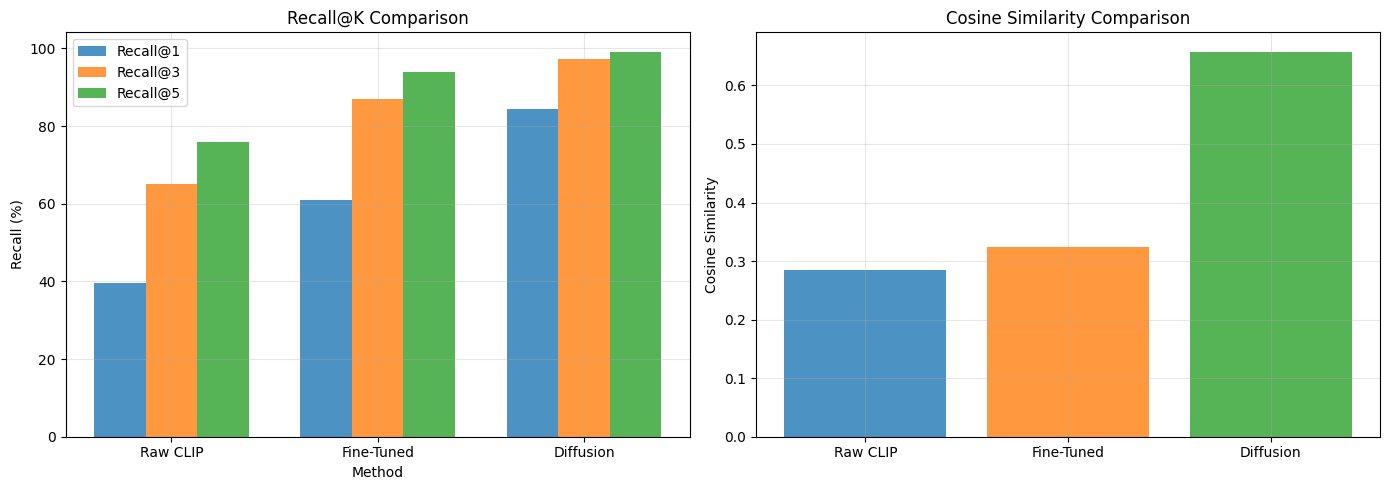

In [10]:
print("=" * 70)
print("PRELIMINARY EXPERIMENTS: Comparing All Methods")
print("=" * 70)

# Evaluate all methods on test set
print("\n1. Evaluating Raw CLIP (baseline)...")
raw_metrics = evaluate_method(test_loader, method="raw")

print("\n2. Evaluating Contrastive Fine-Tuned CLIP...")
baseline_metrics = evaluate_method(test_loader, method="baseline", model=baseline_model)

print("\n3. Evaluating Diffusion Denoising...")
diffusion_metrics = evaluate_method(test_loader, method="diffusion", denoiser=denoiser)

# Create comparison table
comparison_data = {
    "Method": ["Raw CLIP", "Contrastive Fine-Tuned", "Diffusion Denoised"],
    "Recall@1 (%)": [
        f"{raw_metrics['Recall@1']:.2f}",
        f"{baseline_metrics['Recall@1']:.2f}",
        f"{diffusion_metrics['Recall@1']:.2f}"
    ],
    "Recall@3 (%)": [
        f"{raw_metrics['Recall@3']:.2f}",
        f"{baseline_metrics['Recall@3']:.2f}",
        f"{diffusion_metrics['Recall@3']:.2f}"
    ],
    "Recall@5 (%)": [
        f"{raw_metrics['Recall@5']:.2f}",
        f"{baseline_metrics['Recall@5']:.2f}",
        f"{diffusion_metrics['Recall@5']:.2f}"
    ],
    "Cosine Similarity": [
        f"{raw_metrics['CosineMean']:.4f}",
        f"{baseline_metrics['CosineMean']:.4f}",
        f"{diffusion_metrics['CosineMean']:.4f}"
    ]
}

df = pd.DataFrame(comparison_data)
print("\n" + "=" * 70)
print("COMPARISON RESULTS")
print("=" * 70)
print(df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall@K comparison
methods = ["Raw CLIP", "Fine-Tuned", "Diffusion"]
recall1 = [raw_metrics['Recall@1'], baseline_metrics['Recall@1'], diffusion_metrics['Recall@1']]
recall3 = [raw_metrics['Recall@3'], baseline_metrics['Recall@3'], diffusion_metrics['Recall@3']]
recall5 = [raw_metrics['Recall@5'], baseline_metrics['Recall@5'], diffusion_metrics['Recall@5']]

x = np.arange(len(methods))
width = 0.25
axes[0].bar(x - width, recall1, width, label='Recall@1', alpha=0.8)
axes[0].bar(x, recall3, width, label='Recall@3', alpha=0.8)
axes[0].bar(x + width, recall5, width, label='Recall@5', alpha=0.8)
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Recall (%)')
axes[0].set_title('Recall@K Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cosine similarity comparison
cosine_vals = [raw_metrics['CosineMean'], baseline_metrics['CosineMean'], diffusion_metrics['CosineMean']]
axes[1].bar(methods, cosine_vals, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_title('Cosine Similarity Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 7: Hyperparameter Ablation Studies

### 7.1: Ablation on λ₁ and λ₂ (Loss Weights)


In [11]:
print("=" * 70)
print("HYPERPARAMETER ABLATION: λ₁ and λ₂ (Loss Weights)")
print("=" * 70)

# Test different λ₁, λ₂ combinations
lambda_combinations = [
    (0.5, 0.5), (1.0, 1.0), (1.5, 1.5),  # Equal weights
    (1.0, 0.5), (1.0, 1.5),  # Image vs Text emphasis
    (0.5, 1.0), (1.5, 1.0)   # Text vs Image emphasis
]

ablation_results = []

for λ1, λ2 in lambda_combinations:
    print(f"\nTesting λ₁={λ1}, λ₂={λ2}...")

    # Reinitialize denoiser for fair comparison
    test_denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
    test_optimizer = torch.optim.Adam(test_denoiser.parameters(), lr=1e-4)

    # Quick training (fewer epochs for ablation)
    for epoch in range(5):  # Reduced epochs for speed
        test_denoiser.train()
        for images, captions in train_loader:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            t = torch.rand(1).item()
            noisy_img = add_noise_linear(img_embeds, t, 0.3)
            noisy_txt = add_noise_linear(txt_embeds, t, 0.3)

            denoised_img = test_denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
            denoised_txt = test_denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

            mse_loss = λ1 * F.mse_loss(denoised_img, img_embeds) + \
                       λ2 * F.mse_loss(denoised_txt, txt_embeds)
            cont_loss = contrastive_loss(denoised_img, denoised_txt, 0.07)
            loss = mse_loss + cont_loss

            test_optimizer.zero_grad()
            loss.backward()
            test_optimizer.step()

    # Evaluate
    metrics = evaluate_method(val_loader, method="diffusion", denoiser=test_denoiser)
    ablation_results.append({
        "λ₁": λ1, "λ₂": λ2,
        "Recall@1": metrics['Recall@1'],
        "Recall@5": metrics['Recall@5'],
        "Cosine": metrics['CosineMean']
    })
    print(f"  Recall@1: {metrics['Recall@1']:.2f}%, Cosine: {metrics['CosineMean']:.4f}")

# Display results
ablation_df = pd.DataFrame(ablation_results)
print("\n" + "=" * 70)
print("ABLATION RESULTS: λ₁ and λ₂")
print("=" * 70)
print(ablation_df.to_string(index=False))

# Find best combination
best_idx = ablation_df['Recall@1'].idxmax()
best_lambda = ablation_df.loc[best_idx]
print(f"\nBest: λ₁={best_lambda['λ₁']}, λ₂={best_lambda['λ₂']} ")
print(f"  Recall@1: {best_lambda['Recall@1']:.2f}%, Cosine: {best_lambda['Cosine']:.4f}")


HYPERPARAMETER ABLATION: λ₁ and λ₂ (Loss Weights)

Testing λ₁=0.5, λ₂=0.5...
  Recall@1: 73.07%, Cosine: 0.5994

Testing λ₁=1.0, λ₂=1.0...
  Recall@1: 84.38%, Cosine: 0.4617

Testing λ₁=1.5, λ₂=1.5...
  Recall@1: 64.46%, Cosine: 0.4538

Testing λ₁=1.0, λ₂=0.5...
  Recall@1: 79.58%, Cosine: 0.4602

Testing λ₁=1.0, λ₂=1.5...
  Recall@1: 83.58%, Cosine: 0.4465

Testing λ₁=0.5, λ₂=1.0...
  Recall@1: 86.99%, Cosine: 0.4760

Testing λ₁=1.5, λ₂=1.0...
  Recall@1: 76.68%, Cosine: 0.3542

ABLATION RESULTS: λ₁ and λ₂
 λ₁  λ₂  Recall@1  Recall@5   Cosine
0.5 0.5 73.073073 96.996997 0.599441
1.0 1.0 84.384384 99.399399 0.461723
1.5 1.5 64.464464 93.193193 0.453834
1.0 0.5 79.579580 98.298298 0.460245
1.0 1.5 83.583584 99.599600 0.446545
0.5 1.0 86.986987 99.699700 0.475986
1.5 1.0 76.676677 98.598599 0.354233

Best: λ₁=0.5, λ₂=1.0 
  Recall@1: 86.99%, Cosine: 0.4760


### 7.2: Ablation on Noise Schedule


In [12]:
print("=" * 70)
print("HYPERPARAMETER ABLATION: Noise Schedule")
print("=" * 70)

noise_schedules = ["linear", "cosine"]
noise_results = []

for schedule in noise_schedules:
    print(f"\nTesting {schedule} noise schedule...")

    test_denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
    test_optimizer = torch.optim.Adam(test_denoiser.parameters(), lr=1e-4)

    for epoch in range(5):
        test_denoiser.train()
        for images, captions in train_loader:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            t = torch.rand(1).item()

            if schedule == "linear":
                noisy_img = add_noise_linear(img_embeds, t, 0.3)
                noisy_txt = add_noise_linear(txt_embeds, t, 0.3)
            else:
                noisy_img = add_noise_cosine(img_embeds, t, 0.3)
                noisy_txt = add_noise_cosine(txt_embeds, t, 0.3)

            denoised_img = test_denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
            denoised_txt = test_denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

            mse_loss = F.mse_loss(denoised_img, img_embeds) + F.mse_loss(denoised_txt, txt_embeds)
            cont_loss = contrastive_loss(denoised_img, denoised_txt, 0.07)
            loss = mse_loss + cont_loss

            test_optimizer.zero_grad()
            loss.backward()
            test_optimizer.step()

    metrics = evaluate_method(val_loader, method="diffusion", denoiser=test_denoiser)
    noise_results.append({
        "Schedule": schedule,
        "Recall@1": metrics['Recall@1'],
        "Recall@5": metrics['Recall@5'],
        "Cosine": metrics['CosineMean']
    })
    print(f"  Recall@1: {metrics['Recall@1']:.2f}%, Cosine: {metrics['CosineMean']:.4f}")

noise_df = pd.DataFrame(noise_results)
print("\n" + "=" * 70)
print("NOISE SCHEDULE COMPARISON")
print("=" * 70)
print(noise_df.to_string(index=False))


HYPERPARAMETER ABLATION: Noise Schedule

Testing linear noise schedule...
  Recall@1: 80.98%, Cosine: 0.3966

Testing cosine noise schedule...
  Recall@1: 91.69%, Cosine: 0.5976

NOISE SCHEDULE COMPARISON
Schedule  Recall@1  Recall@5   Cosine
  linear 80.980981 99.399399 0.396610
  cosine 91.691692 99.699700 0.597554


### 7.3: Ablation on Max Noise Level


HYPERPARAMETER ABLATION: Max Noise Level

Testing max_noise=0.1...
  Recall@1: 83.28%, Cosine: 0.7163

Testing max_noise=0.2...
  Recall@1: 79.18%, Cosine: 0.6885

Testing max_noise=0.3...
  Recall@1: 77.98%, Cosine: 0.4166

Testing max_noise=0.4...
  Recall@1: 74.67%, Cosine: 0.3194

MAX NOISE LEVEL COMPARISON
 Max Noise  Recall@1  Recall@5   Cosine
       0.1 83.283283 98.998999 0.716252
       0.2 79.179179 97.797798 0.688527
       0.3 77.977978 98.598599 0.416643
       0.4 74.674675 97.497497 0.319377


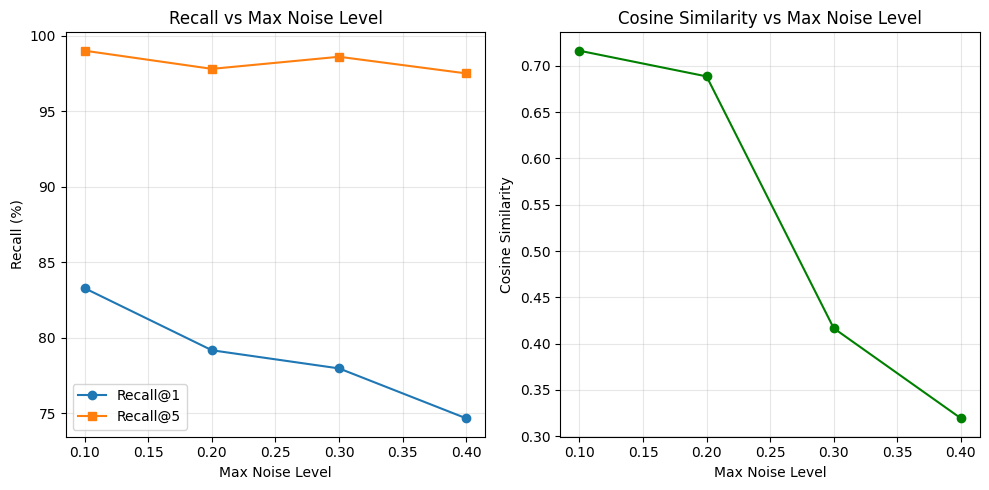

In [13]:
print("=" * 70)
print("HYPERPARAMETER ABLATION: Max Noise Level")
print("=" * 70)

max_noise_levels = [0.1, 0.2, 0.3, 0.4]
noise_level_results = []

for max_noise in max_noise_levels:
    print(f"\nTesting max_noise={max_noise}...")

    test_denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
    test_optimizer = torch.optim.Adam(test_denoiser.parameters(), lr=1e-4)

    for epoch in range(5):
        test_denoiser.train()
        for images, captions in train_loader:
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            t = torch.rand(1).item()
            noisy_img = add_noise_linear(img_embeds, t, max_noise)
            noisy_txt = add_noise_linear(txt_embeds, t, max_noise)

            denoised_img = test_denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
            denoised_txt = test_denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

            mse_loss = F.mse_loss(denoised_img, img_embeds) + F.mse_loss(denoised_txt, txt_embeds)
            cont_loss = contrastive_loss(denoised_img, denoised_txt, 0.07)
            loss = mse_loss + cont_loss

            test_optimizer.zero_grad()
            loss.backward()
            test_optimizer.step()

    metrics = evaluate_method(val_loader, method="diffusion", denoiser=test_denoiser)
    noise_level_results.append({
        "Max Noise": max_noise,
        "Recall@1": metrics['Recall@1'],
        "Recall@5": metrics['Recall@5'],
        "Cosine": metrics['CosineMean']
    })
    print(f"  Recall@1: {metrics['Recall@1']:.2f}%, Cosine: {metrics['CosineMean']:.4f}")

noise_level_df = pd.DataFrame(noise_level_results)
print("\n" + "=" * 70)
print("MAX NOISE LEVEL COMPARISON")
print("=" * 70)
print(noise_level_df.to_string(index=False))

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(noise_level_df['Max Noise'], noise_level_df['Recall@1'], marker='o', label='Recall@1')
plt.plot(noise_level_df['Max Noise'], noise_level_df['Recall@5'], marker='s', label='Recall@5')
plt.xlabel('Max Noise Level')
plt.ylabel('Recall (%)')
plt.title('Recall vs Max Noise Level')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(noise_level_df['Max Noise'], noise_level_df['Cosine'], marker='o', color='green')
plt.xlabel('Max Noise Level')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Max Noise Level')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 8: Final Comparison Summary


In [14]:
print("=" * 70)
print("FINAL COMPARISON: All Methods on Test Set")
print("=" * 70)

# Final evaluation on test set
final_raw = evaluate_method(test_loader, method="raw")
final_baseline = evaluate_method(test_loader, method="baseline", model=baseline_model)
final_diffusion = evaluate_method(test_loader, method="diffusion", denoiser=denoiser)

# Create final comparison table
final_comparison = pd.DataFrame({
    "Method": ["Raw CLIP", "Contrastive Fine-Tuned", "Diffusion Denoised"],
    "Recall@1 (%)": [
        f"{final_raw['Recall@1']:.2f}",
        f"{final_baseline['Recall@1']:.2f}",
        f"{final_diffusion['Recall@1']:.2f}"
    ],
    "Recall@3 (%)": [
        f"{final_raw['Recall@3']:.2f}",
        f"{final_baseline['Recall@3']:.2f}",
        f"{final_diffusion['Recall@3']:.2f}"
    ],
    "Recall@5 (%)": [
        f"{final_raw['Recall@5']:.2f}",
        f"{final_baseline['Recall@5']:.2f}",
        f"{final_diffusion['Recall@5']:.2f}"
    ],
    "Cosine Similarity": [
        f"{final_raw['CosineMean']:.4f}",
        f"{final_baseline['CosineMean']:.4f}",
        f"{final_diffusion['CosineMean']:.4f}"
    ],
    "Improvement over Raw": [
        "-",
        f"+{final_baseline['Recall@1'] - final_raw['Recall@1']:.2f}%",
        f"+{final_diffusion['Recall@1'] - final_raw['Recall@1']:.2f}%"
    ]
})

print(final_comparison.to_string(index=False))

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)
print(f"1. Raw CLIP Baseline:")
print(f"   Recall@1: {final_raw['Recall@1']:.2f}%, Cosine: {final_raw['CosineMean']:.4f}")
print(f"\n2. Contrastive Fine-Tuning:")
print(f"   Recall@1: {final_baseline['Recall@1']:.2f}% (+{final_baseline['Recall@1'] - final_raw['Recall@1']:.2f}%)")
print(f"   Cosine: {final_baseline['CosineMean']:.4f} (+{final_baseline['CosineMean'] - final_raw['CosineMean']:.4f})")
print(f"\n3. Diffusion Denoising:")
print(f"   Recall@1: {final_diffusion['Recall@1']:.2f}% (+{final_diffusion['Recall@1'] - final_raw['Recall@1']:.2f}%)")
print(f"   Cosine: {final_diffusion['CosineMean']:.4f} (+{final_diffusion['CosineMean'] - final_raw['CosineMean']:.4f})")
print("=" * 70)


FINAL COMPARISON: All Methods on Test Set
                Method Recall@1 (%) Recall@3 (%) Recall@5 (%) Cosine Similarity Improvement over Raw
              Raw CLIP        39.50        65.00        75.80            0.2856                    -
Contrastive Fine-Tuned        61.10        86.90        93.90            0.3240              +21.60%
    Diffusion Denoised        84.40        97.20        99.20            0.6578              +44.90%

KEY FINDINGS
1. Raw CLIP Baseline:
   Recall@1: 39.50%, Cosine: 0.2856

2. Contrastive Fine-Tuning:
   Recall@1: 61.10% (+21.60%)
   Cosine: 0.3240 (+0.0385)

3. Diffusion Denoising:
   Recall@1: 84.40% (+44.90%)
   Cosine: 0.6578 (+0.3723)
